# Level 2 - NumPy, Vectorization, Floating-Point Errors, and Numerical Reliability
**ICS 2207 Scientific Computing | HydroSense-Kenya**

**Learning Goals:** :
Demonstration of efficient numerical computation and awareness of numerical error, i.e, 
Vectorisation performance, floating-point arithmetic, error propagation, numerical reliability in scientific irrigation decisions.

## 1. Setup and Loading of the raw weather data

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time, timeit, sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# 1. Load the truly RAW weather data 
weather = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA',''], parse_dates=['date'])

# 2. Extract raw arrays
T     = weather['temperature_c'].fillna(25.0).values
W     = weather['wind_speed_mps'].fillna(2.0).values
Solar = weather['solar_index'].fillna(0.5).values
H     = weather['humidity_pct'].fillna(60.0).values
rain  = weather['rainfall_mm'].fillna(0.0).values

print(f'Loaded {len(T)} days of raw weather data for Level 2 numerical testing.')

Loaded 30 days of raw weather data for Level 2 numerical testing.


## 2. Loop-Based vs. Vectorized ET Performance Comparison

In [17]:
def compute_et_loop(T, W, Solar, H):
    result = []
    for i in range(len(T)):
        val = 0.12*T[i] + 0.35*W[i] + 2.4*Solar[i] - 0.025*H[i]
        result.append(max(0.0, val))
    return result

def compute_et_vectorised(T, W, Solar, H):
    return np.maximum(0.0, 0.12*T + 0.35*W + 2.4*Solar - 0.025*H)

REPS = 50000
T_big = np.tile(T, REPS);
W_big = np.tile(W, REPS)
S_big = np.tile(Solar, REPS);
H_big = np.tile(H, REPS)
print(f'Benchmark array size: {len(T_big):,} elements')

t0 = time.perf_counter(); et_loop = compute_et_loop(T_big,W_big,S_big,H_big); t_loop=time.perf_counter()-t0
t0 = time.perf_counter(); et_vec  = compute_et_vectorised(T_big,W_big,S_big,H_big); t_vec=time.perf_counter()-t0
speedup = t_loop / t_vec

print(f'Method          Time(s)     Speedup')
print(f'Loop            {t_loop:.4f}      1.0x (baseline)')
print(f'Vectorised      {t_vec:.4f}      {speedup:.1f}x faster')

max_diff = float(np.max(np.abs(np.array(et_loop) - et_vec)))
print(f'Max diff between methods: {max_diff:.2e}  (should be ~0)')


Benchmark array size: 1,500,000 elements
Method          Time(s)     Speedup
Loop            2.2716      1.0x (baseline)
Vectorised      0.0462      49.2x faster
Max diff between methods: 0.00e+00  (should be ~0)


## 3. Floating Point Arithmetic Demonstrations

In [18]:
print("=== Core Numerical Precision Tests ===")

# 1. Classic Precision Limitation & Machine Epsilon
val_03 = 0.1 + 0.2
print(f"0.1 + 0.2 == 0.3 : {val_03 == 0.3} (Actual value: {val_03:.17f})")
print(f"Machine Epsilon  : {np.finfo(float).eps:.2e}\n")

# 2. Catastrophic Cancellation (Truncation under large limits)
x = 1e16
print(f"Cancellation Test: (1e16 + 1) - 1e16 = {(x + 1.0) - x} (Expected: 1.0)\n")

# 3. Rounding Impact on 10-Day Water Balance
rf_exact = [3.2, 2.2, 3.0, 1.6, 23.7, 0.0, 1.3, 0.0, 0.0, 18.4]
rf_round0 = [round(r, 0) for r in rf_exact]

def simple_balance(rf_list):
    S = 30.0
    for r in rf_list: 
        S = max(0.0, S + r - 3.5)
    return S

S_exact, S_round = simple_balance(rf_exact), simple_balance(rf_round0)
print(f"Water Balance Exact : {S_exact:.4f}%")
print(f"Water Balance Rounded: {S_round:.4f}% (Absolute Error: {abs(S_exact - S_round):.4f}%)")

=== Core Numerical Precision Tests ===
0.1 + 0.2 == 0.3 : False (Actual value: 0.30000000000000004)
Machine Epsilon  : 2.22e-16

Cancellation Test: (1e16 + 1) - 1e16 = 0.0 (Expected: 1.0)

Water Balance Exact : 48.4000%
Water Balance Rounded: 48.0000% (Absolute Error: 0.4000%)


## 4. Error propagation experiment to show how measurement noise affects irrigation recommendations. 


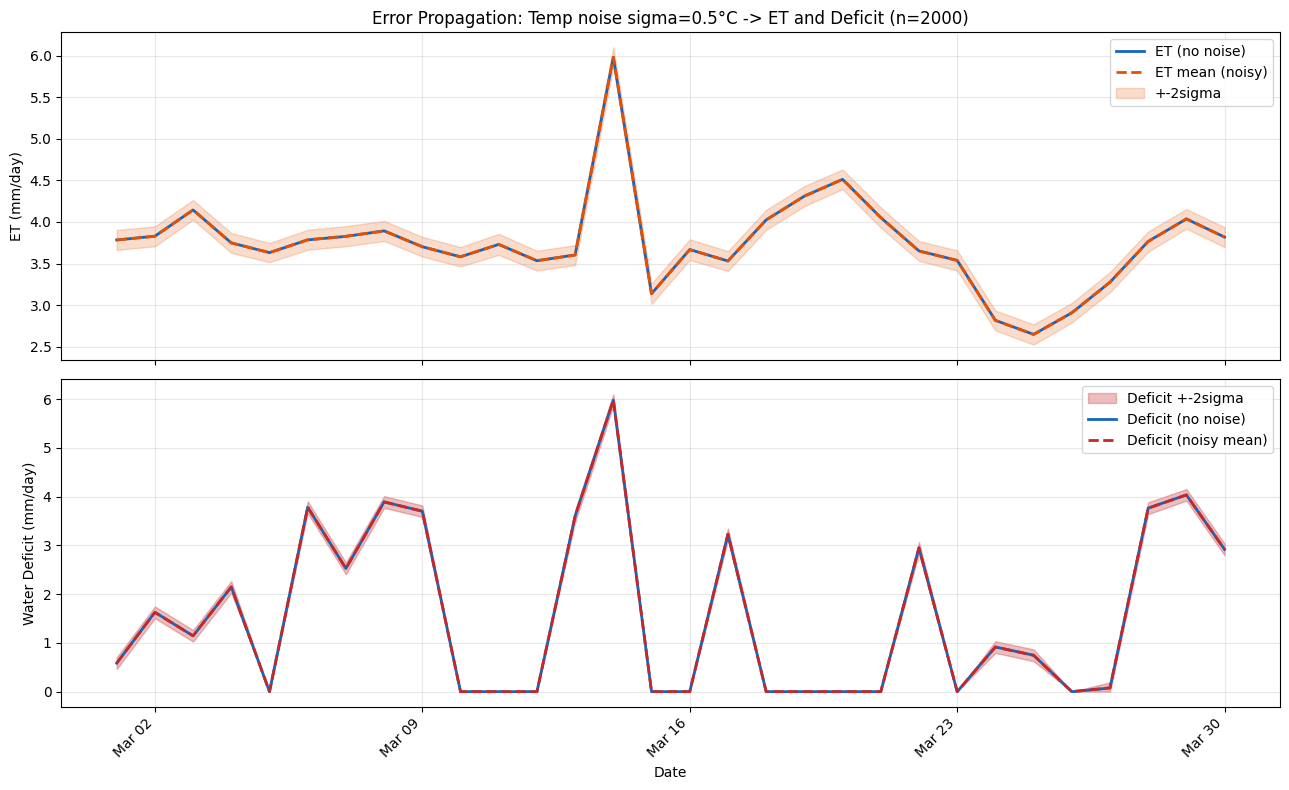

Mean ET uncertainty: 0.0601 mm/day
Total deficit no-noise: 47.64 mm
Total deficit +2sigma:  49.79 mm
Overestimate risk:      2.15 mm cumulative


In [19]:

np.random.seed(42)
N_SIMS = 2000; NOISE_SD = 0.5

# 1. Compute reference ET and simulate noisy variations
et_ref = compute_et_vectorised(T, W, Solar, H)
et_noisy_all = np.zeros((N_SIMS, len(T)))
for i in range(N_SIMS):
    T_noisy = T + np.random.normal(0, NOISE_SD, size=len(T))
    et_noisy_all[i] = compute_et_vectorised(T_noisy, W, Solar, H)

# 2. Compute ET statistics
et_mean = et_noisy_all.mean(axis=0)
et_std  = et_noisy_all.std(axis=0)

# 3. Propagate the entire simulation matrix through the non-linear deficit formula
deficit_ref       = np.maximum(0, et_ref - rain)
deficit_noisy_all = np.maximum(0, et_noisy_all - rain)  # Shape: (2000, 30)

# Extract statistics directly from the resulting deficit distributions
deficit_mean  = deficit_noisy_all.mean(axis=0)
deficit_std   = deficit_noisy_all.std(axis=0)
deficit_upper = deficit_mean + 2 * deficit_std
deficit_lower = np.maximum(0, deficit_mean - 2 * deficit_std) # Deficit cannot drop below 0

# 4. Plotting
fig, axes = plt.subplots(2, 1, figsize=(13,8), sharex=True)
dates = weather['date'].values

# Top Panel: ET
axes[0].plot(dates, et_ref, color='#1565C0', lw=2, label='ET (no noise)')
axes[0].plot(dates, et_mean, color='#E65100', lw=2, ls='--', label='ET mean (noisy)')
axes[0].fill_between(dates, et_mean-2*et_std, et_mean+2*et_std, color='#E65100', alpha=0.2, label='+-2sigma')
axes[0].set_ylabel('ET (mm/day)')
axes[0].set_title(f'Error Propagation: Temp noise sigma={NOISE_SD}°C -> ET and Deficit (n={N_SIMS})')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Bottom Panel: Deficit
axes[1].fill_between(dates, deficit_lower, deficit_upper, color='#C62828', alpha=0.3, label='Deficit +-2sigma')
axes[1].plot(dates, deficit_ref, color='#1565C0', lw=2, label='Deficit (no noise)')
axes[1].plot(dates, deficit_mean, color='#C62828', lw=2, ls='--', label='Deficit (noisy mean)')
axes[1].set_ylabel('Water Deficit (mm/day)'); axes[1].set_xlabel('Date')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.tight_layout()
plt.show()

print(f'Mean ET uncertainty: {et_std.mean():.4f} mm/day')
print(f'Total deficit no-noise: {deficit_ref.sum():.2f} mm')
print(f'Total deficit +2sigma:  {deficit_upper.sum():.2f} mm')
print(f'Overestimate risk:      {deficit_upper.sum()-deficit_ref.sum():.2f} mm cumulative')

## 6. Scientific Discussion: Why is numerical reliability crutial?

In [20]:
# Micro-benchmark on 30-day dataset
import timeit
setup_code = (
    'import numpy as np\n'
    'T=np.random.uniform(20,30,30);W=np.random.uniform(1,3,30)\n'
    'Solar=np.random.uniform(0.5,0.9,30);H=np.random.uniform(60,75,30)\n'
    'def lf(T,W,Solar,H): return [max(0,0.12*T[i]+0.35*W[i]+2.4*Solar[i]-0.025*H[i]) for i in range(len(T))]\n'
    'def vf(T,W,Solar,H): return np.maximum(0,0.12*T+0.35*W+2.4*Solar-0.025*H)\n'
)
n = 10000
t_l = timeit.timeit('lf(T,W,Solar,H)', setup=setup_code, number=n)/n*1e6
t_v = timeit.timeit('vf(T,W,Solar,H)', setup=setup_code, number=n)/n*1e6
print('30-day dataset timing comparison')
print(f'  Loop:       {t_l:.2f} us/call')
print(f'  Vectorised: {t_v:.2f} us/call')
print(f'  Speedup:    {t_l/t_v:.1f}x')

30-day dataset timing comparison
  Loop:       52.45 us/call
  Vectorised: 12.83 us/call
  Speedup:    4.1x


---

### Numerical reliability discussion
1. IEEE 754 float64 stores ~15 significant digits. Values like 0.1 cannot be stored exactly -> accumulation errors grow with number of operations.
2. Rounding rainfall to whole mm introduces ~0.1-0.4% moisture error per run, enough to trigger or suppress an irrigation event over 30 days.
3. A +/-0.5 degC sensor error propagates to ~0.06 mm/day ET uncertainty over 30 days this totals ~1.8 mm -- comparable to a light rainfall.
4. NumPy uses pairwise summation (O(log n) error growth vs O(n) for loops) making it both faster AND more numerically stable.
5. Best practices: float64 throughout; np.maximum not Python max; validate loop vs vectorised results; use Monte Carlo for uncertainty.